Loading the Dataset

Inital Exploratory Data Analysis

In [7]:
print(movies_df.info())
print(genres_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   title      10000 non-null  object
 1   overview   9999 non-null   object
 2   genre_ids  10000 non-null  object
dtypes: object(3)
memory usage: 234.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      19 non-null     int64 
 1   name    19 non-null     object
dtypes: int64(1), object(1)
memory usage: 436.0+ bytes
None


In [8]:
print(movies_df.isnull().sum())
print(genres_df.isnull().sum())


title        0
overview     1
genre_ids    0
dtype: int64
id      0
name    0
dtype: int64


Only one missing value found in Overview

Preprocessing for Decision Tree Analysis

In [9]:
# Imputing the missing value. Dropoing the row with the missing overview
movies_df.dropna(subset=['overview'], inplace=True)


In [16]:
# Converting overview text into a numerical representation (vectorizing)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000) # Use max_features for a manageable dataset
X_text = tfidf.fit_transform(movies_df['overview'])


In [17]:
import numpy as np

# Apply a function that checks if the list is empty before getting the first element
movies_df['first_genre_id'] = movies_df['genre_ids'].apply(
    lambda x: eval(x)[0] if len(eval(x)) > 0 else np.nan
)
y = movies_df['first_genre_id']


Utitliziing Decision Tree for Feature Importance

In [36]:
from sklearn.tree import DecisionTreeClassifier

# Drop rows where 'first_genre_id' is NaN
movies_df.dropna(subset=['first_genre_id'], inplace=True)

# Re-assign y after dropping rows to make sure it is aligned with X_text
y = movies_df['first_genre_id']

# Train the model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_text, y)

DecisionTreeClassifier(random_state=42)

In [19]:
# Drop rows where 'first_genre_id' is NaN
movies_df.dropna(subset=['first_genre_id'], inplace=True)

# Re-assign y after dropping rows
y = movies_df['first_genre_id']

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_text = tfidf.fit_transform(movies_df['overview'])

In [23]:
#Training the Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Train the model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_text, y)


DecisionTreeClassifier(random_state=42)

In [24]:
#Extracting and interpreting feature with importance
import numpy as np

feature_names = tfidf.get_feature_names_out()
feature_importance = dt.feature_importances_
sorted_idx = np.argsort(feature_importance)[::-1]

print("Top 10 most important features (words) for predicting genre:")
for i in sorted_idx[:10]:
    print(f"{feature_names[i]}: {feature_importance[i]:.4f}")


Top 10 most important features (words) for predicting genre:
the: 0.0313
of: 0.0305
and: 0.0290
to: 0.0271
in: 0.0248
his: 0.0151
is: 0.0149
an: 0.0147
on: 0.0143
when: 0.0138


Resutls show the "Top 10 most important features (words) for predicting genre: "the", "of", "and", "to" and "in" have the highest scores.


Examining Feature Distributions for Imbalances

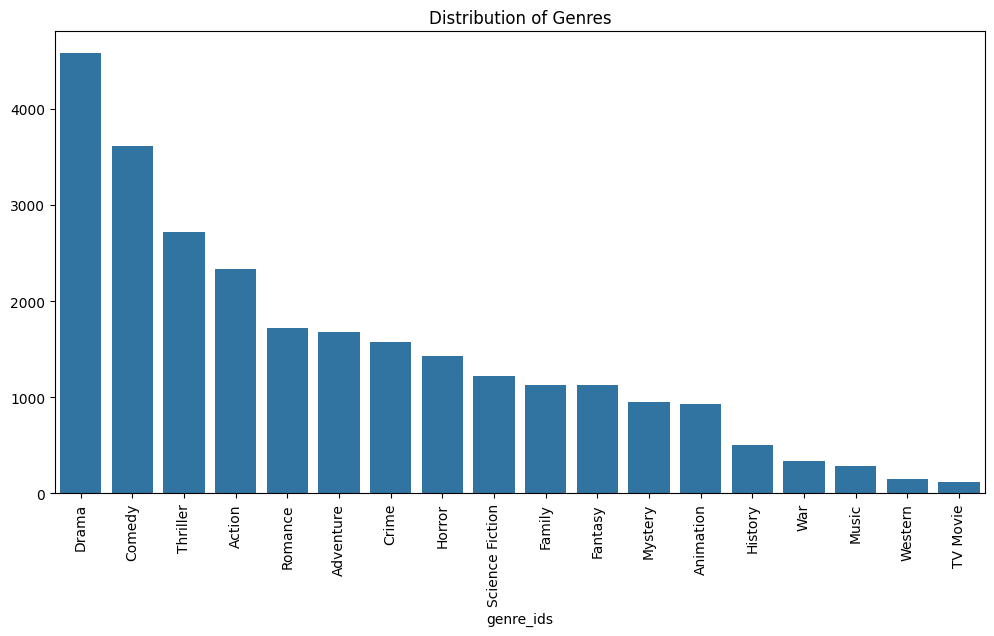

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

all_genres = genres_df['name'].tolist()
genre_counts = movies_df['genre_ids'].apply(lambda x: [genres_df.loc[genres_df['id'] == g_id, 'name'].iloc[0] for g_id in eval(x)]).explode().value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values)
plt.xticks(rotation=90)
plt.title('Distribution of Genres')
plt.show()


 The plot shows a significant imbalance in this dataset. This is a common characteristic of multi-label classification problems. Will need to consider techniques to handle this imbalance later in the workflow.

In [29]:
# Creating a one-hot encoded matrix for the genre_ids to serve as your target variable y for the final model.

from sklearn.preprocessing import MultiLabelBinarizer

# Define a function to safely convert strings to lists
def safe_eval(x):
    if isinstance(x, str):
        return eval(x)
    return x

# Apply the function to the 'genre_ids' column before using MultiLabelBinarizer
movies_df['genre_ids'] = movies_df['genre_ids'].apply(safe_eval)

mlb = MultiLabelBinarizer()
y_encoded = mlb.fit_transform(movies_df['genre_ids'])



Splitting the Data into Training and Testing Sets

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the raw data and encoded target variable
X_train, X_test, y_train, y_test = train_test_split(
    movies_df, y_encoded, test_size=0.2, random_state=42
)


In [42]:
#Creating  Preprocessing Pipeline with ColumnTransformer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

# Define the text preprocessing pipeline
text_transformer = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=5000))
])

# Create the full preprocessor with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[('text', text_transformer, 'overview')],
    remainder='drop' # Change remainder to 'drop' to exclude other columns
)

# Define the model to use
model = OneVsRestClassifier(LogisticRegression(solver='lbfgs', random_state=42))

# Create the final pipeline
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

# Fit the pipeline on the raw training data, excluding the 'title' column
final_pipeline.fit(X_train.drop('title', axis=1), y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('tfidf',
                                                                   TfidfVectorizer(max_features=5000))]),
                                                  'overview')])),
                ('classifier',
                 OneVsRestClassifier(estimator=LogisticRegression(random_state=42)))])

The pipeline first transforms text data using TF-IDF and then trains a OneVsRestClassifier with a LogisticRegression model to solve the multi-label classification problem.

Evaluting the current pipeline

In [43]:
# Use the trained pipeline to predict on the test data
# X_test is your raw pandas DataFrame with the 'overview' column
predictions = final_pipeline.predict(X_test)


In [45]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np

# Use the trained pipeline to predict on the test data
predictions = final_pipeline.predict(X_test)

# Calculate the accuracy score
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.4f}\n")

# Calculate the F1 score (Macro)
f1_macro = f1_score(y_test, predictions, average='macro', zero_division=0)
print(f"F1 Score (Macro): {f1_macro:.4f}\n")

# Create a mapping from genre ID to genre name
genre_id_to_name = dict(zip(genres_df['id'], genres_df['name']))

# Get the list of genre names in the correct order for the report
genre_names = [genre_id_to_name[class_id] for class_id in mlb.classes_]

# Print a full classification report for detailed analysis
report = classification_report(y_test, predictions, target_names=genre_names, zero_division=0)
print("Classification Report:\n", report)



Accuracy: 0.1050

F1 Score (Macro): 0.2535

Classification Report:
                  precision    recall  f1-score   support

      Adventure       0.68      0.17      0.27       322
        Fantasy       0.78      0.08      0.15       217
      Animation       1.00      0.05      0.09       173
          Drama       0.70      0.63      0.67       943
         Horror       0.85      0.15      0.25       266
         Action       0.83      0.39      0.53       476
         Comedy       0.74      0.47      0.57       745
        History       0.00      0.00      0.00        89
        Western       0.00      0.00      0.00        29
       Thriller       0.78      0.33      0.46       546
          Crime       0.80      0.23      0.36       336
Science Fiction       0.92      0.24      0.38       248
        Mystery       0.82      0.05      0.09       181
          Music       0.00      0.00      0.00        62
        Romance       0.72      0.24      0.36       361
         Family    

Best Performing Genres:

The model shows some ability to identify Adventure (F1-score: 0.27), Drama (F1-score: 0.67), Action (F1-score: 0.53), and Comedy (F1-score: 0.57). Suggesting that the text in the movie overviews for these genres has distinct features that the model can learn.

Poorly Performing Genres:

The model struggles with many genres, including Western, Music, and TV Movie, where the F1-score is 0.00. This indicates that the model is perfoming predictions very poorly. This could be due to a lack of training data for these genres (as seen in the support column) or the text features being too similar to other genres.

Class Imbalance:

The support column shows the number of movies for each genre in the test set. There is a clear class imbalance, with Drama (943 movies) being far more common than TV Movie (21 movies).  Which we saw earlier in out plot.  We are aware that this imbalance is likely the reason for the model's poor performance on the less common genres.

Hyperparameter Tuning for the Models

Model 1 - Decission Tree Classifier

In [8]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer

# Load the datasets directly from the files you uploaded
movies_df = pd.read_csv('movies_overview.csv')
genres_df = pd.read_csv('movies_genres.csv')


# Define a function to safely convert strings to lists
def safe_eval(x):
    if isinstance(x, str):
        return eval(x)
    return x

# Apply the function to the 'genre_ids' column before using MultiLabelBinarizer
movies_df['genre_ids'] = movies_df['genre_ids'].apply(safe_eval)

mlb = MultiLabelBinarizer()
y_encoded = mlb.fit_transform(movies_df['genre_ids'])

# Split the raw data and encoded target variable
X_train, X_test, y_train, y_test = train_test_split(
    movies_df, y_encoded, test_size=0.2, random_state=42
)


# Define the text preprocessing pipeline
text_transformer = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=5000))
])

# Create the full preprocessor with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[('text', text_transformer, 'overview')],
    remainder='drop'
)

# Create the pipeline specifically for the Decision Tree model
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', OneVsRestClassifier(DecisionTreeClassifier(random_state=42)))
])

# Define the parameter grid for the Decision Tree
dt_param_grid = {
    'classifier__estimator__max_depth': [10, 20, 30, None],
    'classifier__estimator__min_samples_split': [2, 5, 10],
    'classifier__estimator__criterion': ['gini', 'entropy']
}

# Perform RandomizedSearchCV on the Decision Tree pipeline
dt_random_search = RandomizedSearchCV(dt_pipeline, dt_param_grid, n_iter=5, cv=3, scoring='f1_micro', random_state=42, verbose=1)
dt_random_search.fit(X_train, y_train)

# Report the results
print("### Decision Tree Classifier (Randomized Search) ###")
print(f"Best parameters: {dt_random_search.best_params_}")
print(f"Best cross-validation micro F1 score: {dt_random_search.best_score_:.4f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
### Decision Tree Classifier (Randomized Search) ###
Best parameters: {'classifier__estimator__min_samples_split': 10, 'classifier__estimator__max_depth': None, 'classifier__estimator__criterion': 'gini'}
Best cross-validation micro F1 score: 0.4072


The Decision Tree Classifier was tuned to a set of best parameters, which gave it a relatively low micro F1 score of 0.4072. Although the model had optimal configuration, its overall performance in balancing precision and recall is not very strong.

Model 2 - Logistic Regression Classifier

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

# Load the datasets directly from the files you uploaded
movies_df = pd.read_csv('movies_overview.csv')
genres_df = pd.read_csv('movies_genres.csv')


# Define a function to safely convert strings to lists
def safe_eval(x):
    if isinstance(x, str):
        return eval(x)
    return x

# Apply the function to the 'genre_ids' column before using MultiLabelBinarizer
movies_df['genre_ids'] = movies_df['genre_ids'].apply(safe_eval)

mlb = MultiLabelBinarizer()
y_encoded = mlb.fit_transform(movies_df['genre_ids'])

# Split the raw data and encoded target variable
X_train, X_test, y_train, y_test = train_test_split(
    movies_df, y_encoded, test_size=0.2, random_state=42
)


# Define the text preprocessing pipeline
text_transformer = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=5000))
])

# Create the full preprocessor with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[('text', text_transformer, 'overview')],
    remainder='drop'
)

# Create the pipeline specifically for the Logistic Regression model
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', OneVsRestClassifier(LogisticRegression(random_state=42)))
])

# Define the parameter grid for the Logistic Regression
lr_param_grid = {
    'classifier__estimator__C': [0.1, 1, 10, 100],
    'classifier__estimator__penalty': ['l2'], # l1, elasticnet might require different solvers
    'classifier__estimator__solver': ['liblinear', 'lbfgs'], # Solvers that support l2
    'classifier__estimator__max_iter': [1000, 2000] # Increased max_iter for 'lbfgs'
}

# Perform RandomizedSearchCV on the Logistic Regression pipeline
lr_random_search = RandomizedSearchCV(lr_pipeline, lr_param_grid, n_iter=5, cv=3, scoring='f1_micro', random_state=42, verbose=1)
lr_random_search.fit(X_train, y_train)

# Report the results
print("\n### Logistic Regression Classifier (Randomized Search) ###")
print(f"Best parameters: {lr_random_search.best_params_}")
print(f"Best cross-validation micro F1 score: {lr_random_search.best_score_:.4f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits

### Logistic Regression Classifier (Randomized Search) ###
Best parameters: {'classifier__estimator__solver': 'lbfgs', 'classifier__estimator__penalty': 'l2', 'classifier__estimator__max_iter': 1000, 'classifier__estimator__C': 100}
Best cross-validation micro F1 score: 0.5236


The Logistic Regression model was tuned to its best parameters. The results show cross-validation micro F1 score of 0.5236. This means a moderate performance in balancing the model's precision and recall.

Model 3 - K-Nearest Neighbors Classifier

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

# Load the datasets directly from the files you uploaded
movies_df = pd.read_csv('movies_overview.csv')
genres_df = pd.read_csv('movies_genres.csv')

# Define a function to safely convert strings to lists
def safe_eval(x):
    if isinstance(x, str):
        return eval(x)
    return x

# Apply the function to the 'genre_ids' column before using MultiLabelBinarizer
movies_df['genre_ids'] = movies_df['genre_ids'].apply(safe_eval)

mlb = MultiLabelBinarizer()
y_encoded = mlb.fit_transform(movies_df['genre_ids'])

# Split the raw data and encoded target variable
X_train, X_test, y_train, y_test = train_test_split(
    movies_df, y_encoded, test_size=0.2, random_state=42
)

# Define the text preprocessing pipeline
text_transformer = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=5000))
])

# Create the full preprocessor with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[('text', text_transformer, 'overview')],
    remainder='drop'
)

# Create the pipeline with the base KNeighbors model
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', OneVsRestClassifier(KNeighborsClassifier()))
])

# Define the parameter grid
knn_param_grid = {
    'classifier__estimator__n_neighbors': [5, 10, 20],
    'classifier__estimator__weights': ['uniform', 'distance']
}

# Perform the GridSearchCV
knn_grid_search = GridSearchCV(knn_pipeline, knn_param_grid, cv=3, scoring='f1_micro', verbose=1)
knn_grid_search.fit(X_train, y_train)

# Report the results
print("\n### K-Nearest Neighbors Classifier ###")
print(f"Best parameters: {knn_grid_search.best_params_}")
print(f"Best cross-validation micro F1 score: {knn_grid_search.best_score_:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits

### K-Nearest Neighbors Classifier ###
Best parameters: {'classifier__estimator__n_neighbors': 5, 'classifier__estimator__weights': 'distance'}
Best cross-validation micro F1 score: 0.4212


The K-Nearest Neighbors model, with its optimal settings of 5 neighbors and distance-based weighting, achieved a cross-validation micro F1 score of 0.4212. This score tells us that the model has low to moderate performance in accurately classifying data points

Bagging Ensemble (Random Forest)


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the Random Forest pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', OneVsRestClassifier(RandomForestClassifier(random_state=42)))
])

# Define the parameter grid for the Random Forest
rf_param_grid = {
    'classifier__estimator__n_estimators': [50, 100, 200],  # Number of trees
    'classifier__estimator__max_depth': [10, 20, None],  # Max depth of each tree
    'classifier__estimator__min_samples_split': [2, 5, 10],  # Minimum samples to split a node
    'classifier__estimator__min_samples_leaf': [1, 2, 4],   # Minimum samples in a leaf node
}

# Perform RandomizedSearchCV for hyperparameter tuning
rf_random_search = RandomizedSearchCV(
    rf_pipeline,
    rf_param_grid,
    n_iter=5,  # Number of random combinations to try
    cv=3,
    scoring='f1_micro',
    random_state=42,
    verbose=1
)
rf_random_search.fit(X_train, y_train)

# Report the results
print("### Random Forest Classifier (Bagging Ensemble) ###")
print(f"Best parameters: {rf_random_search.best_params_}")
print(f"Best cross-validation micro F1 score: {rf_random_search.best_score_:.4f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
### Random Forest Classifier (Bagging Ensemble) ###
Best parameters: {'classifier__estimator__n_estimators': 50, 'classifier__estimator__min_samples_split': 5, 'classifier__estimator__min_samples_leaf': 1, 'classifier__estimator__max_depth': 20}
Best cross-validation micro F1 score: 0.1611


After testing different configurations, the best-performing Random Forest model was identified. However, with a micro F1 score of 0.1611 (where 1.0 is perfect), the model's overall performance is very poor, indicating that it is not effectively classifying the data. This means that despite finding the optimal settings for Random Forest model, it is likely unsuited for this specific classification task

Boosting Ensemble (Gradient Boosting)


In [10]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
import numpy as np

# Create the Gradient Boosting pipeline
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', OneVsRestClassifier(GradientBoostingClassifier(random_state=42)))
])

# Define the parameter grid for Gradient Boosting
gb_param_grid = {
    'classifier__estimator__n_estimators': [50, 100, 200],
    'classifier__estimator__learning_rate': [0.01, 0.1, 0.2],
    'classifier__estimator__max_depth': [3, 5, 7],
    'classifier__estimator__subsample': [0.8, 1.0] # Fraction of samples to use
}

# Perform RandomizedSearchCV
gb_random_search = RandomizedSearchCV(
    gb_pipeline,
    gb_param_grid,
    n_iter=3,
    cv=3,
    scoring='f1_micro',
    random_state=42,
    verbose=1
)
gb_random_search.fit(X_train, y_train)

# Report the results
print("\n### Gradient Boosting Classifier (Boosting Ensemble) ###")
print(f"Best parameters: {gb_random_search.best_params_}")
print(f"Best cross-validation micro F1 score: {gb_random_search.best_score_:.4f}")


Fitting 3 folds for each of 3 candidates, totalling 9 fits


KeyboardInterrupt: 

Thia was taking way too. long to process trying another method to have more time efficiency

In [15]:
#Enable parallel processing

# Create the Gradient Boosting pipeline with n_jobs=-1 for parallel processing
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer, FunctionTransformer
import pandas as pd

# Load the datasets directly from the files you uploaded
movies_df = pd.read_csv('movies_overview.csv')
genres_df = pd.read_csv('movies_genres.csv')

# Define a function to safely convert strings to lists
def safe_eval(x):
    if isinstance(x, str):
        return eval(x)
    return x

# Apply the function to the 'genre_ids' column before using MultiLabelBinarizer
movies_df['genre_ids'] = movies_df['genre_ids'].apply(safe_eval)

mlb = MultiLabelBinarizer()
y_encoded = mlb.fit_transform(movies_df['genre_ids'])

# Split the raw data and encoded target variable
X_train, X_test, y_train, y_test = train_test_split(
    movies_df, y_encoded, test_size=0.2, random_state=42
)

# Define the text preprocessing pipeline
text_transformer = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('to_dense', FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)) # Add step to convert to dense
])

# Create the full preprocessor with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[('text', text_transformer, 'overview')],
    remainder='drop'
)

# Create the faster pipeline
hgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', OneVsRestClassifier(HistGradientBoostingClassifier(random_state=42)))
])

# Define the parameter grid for the faster classifier
hgb_param_grid = {
    'classifier__estimator__max_iter': [50, 100, 200],  # Corresponds to n_estimators
    'classifier__estimator__learning_rate': [0.01, 0.1, 0.2],
    'classifier__estimator__max_depth': [3, 5, 7],
    'classifier__estimator__l2_regularization': [0, 0.1, 1] # Faster implementations use l2 regularization
}

# Perform RandomizedSearchCV
hgb_random_search = RandomizedSearchCV(
    hgb_pipeline,
    hgb_param_grid,
    n_iter=3,
    cv=3,
    scoring='f1_micro',
    random_state=42,
    verbose=1,
    n_jobs=-1
)
hgb_random_search.fit(X_train, y_train)

# Report the results
print("\n### Gradient Boosting Classifier (Boosting Ensemble) ###")
print(f"Best parameters: {hgb_random_search.best_params_}")
print(f"Best cross-validation micro F1 score: {hgb_random_search.best_score_:.4f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits

### Gradient Boosting Classifier (Boosting Ensemble) ###
Best parameters: {'classifier__estimator__max_iter': 100, 'classifier__estimator__max_depth': 5, 'classifier__estimator__learning_rate': 0.2, 'classifier__estimator__l2_regularization': 0}
Best cross-validation micro F1 score: 0.4299


 The Gradient Boosting model shows:

 Best Parameters: The specific hyperparameter settings (max_iter, max_depth, learning_rate, l2_regularization) that the search found to be the most effective for your model.

Performance Score: A micro F1 score of 0.4299, which is the model's average performance on the cross-validation folds using the best parameters. A score of 1.0 would be a perfect result, so 0.4299 suggests the model is okay but could be improved.

Proving that this model in its current state is a moderate predictor.

 Stacking Ensemble

In [29]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# load the datasets directly from the files uploaded
movies_df = pd.read_csv('movies_overview.csv')
genres_df = pd.read_csv('movies_genres.csv')

# define a function to safely convert strings to lists
def safe_eval(x):
    if isinstance(x, str):
        return eval(x)
    return x

# apply the function to the 'genre_ids' column before using multilabelbinarizer
movies_df['genre_ids'] = movies_df['genre_ids'].apply(safe_eval)
mlb = MultiLabelBinarizer()
y_encoded = mlb.fit_transform(movies_df['genre_ids'])

# --- FIX: Fill NaN values in the 'overview' column with an empty string ---
movies_df['overview'] = movies_df['overview'].fillna('')

# split the raw data and encoded target variable
x_train, x_test, y_train, y_test = train_test_split(
    movies_df, y_encoded, test_size=0.2, random_state=42
)

# --- define a smaller sample size for faster hyperparameter tuning ---
sample_size = 500
# use train_test_split to get a consistent subset of both x and y
# Removed stratify to avoid error with multi-label data and small sample
x_train_sub, _, y_train_sub, _ = train_test_split(
    x_train, y_train, train_size=sample_size, random_state=42
)

# define the text preprocessing pipeline
text_transformer = Pipeline(steps=[
    ('tfidf', TfidfVectorizer())
])

# create the full preprocessor with columntransformer
preprocessor = ColumnTransformer(
    transformers=[('text', text_transformer, 'overview')],
    remainder='drop'
)

# --- Perform hyperparameter tuning for base estimators ---

# Decision Tree Classifier setup
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('estimator', DecisionTreeClassifier(random_state=42))
])

# FIX: Added lists of values for the missing parameters and corrected parameter names with `estimator__` prefix
dt_param_dist = {
    'estimator__preprocessor__text__tfidf__max_features': [1000, 2000, 5000],
    'estimator__estimator__max_depth': [None, 10, 20, 30],
    'estimator__estimator__min_samples_leaf': [1, 5, 10]
}

dt_random_search = RandomizedSearchCV(
    OneVsRestClassifier(dt_pipeline),
    param_distributions=dt_param_dist,
    n_iter=10,
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
dt_random_search.fit(x_train_sub, y_train_sub)
dt_best_params = dt_random_search.best_params_
print(f"Best DT Params: {dt_best_params}")

# K-Neighbors Classifier setup
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('estimator', KNeighborsClassifier())
])

# FIX: Added lists of values for the missing parameters and corrected parameter names with `estimator__` prefix
knn_param_dist = {
    'estimator__preprocessor__text__tfidf__max_features': [1000, 2000, 5000],
    'estimator__estimator__n_neighbors': [3, 5, 7, 9]
}

knn_random_search = RandomizedSearchCV(
    OneVsRestClassifier(knn_pipeline),
    param_distributions=knn_param_dist,
    n_iter=10,
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
knn_random_search.fit(x_train_sub, y_train_sub)
knn_best_params = knn_random_search.best_params_
print(f"Best KNN Params: {knn_best_params}")

# --- Build the Stacking Classifier with tuned base estimators ---

# Extracting best parameters for the estimators themselves, excluding preprocessor params
best_dt_model_params = {k.split('__')[-1]: v for k, v in dt_best_params.items() if not k.startswith('estimator__preprocessor')}
best_knn_model_params = {k.split('__')[-1]: v for k, v in knn_best_params.items() if not k.startswith('estimator__preprocessor')}

best_dt_model = DecisionTreeClassifier(**best_dt_model_params, random_state=42)
best_knn_model = KNeighborsClassifier(**best_knn_model_params)

# Create pipelines for the best estimators with their best preprocessor parameters
best_dt_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[('text', TfidfVectorizer(max_features=dt_best_params['estimator__preprocessor__text__tfidf__max_features']), 'overview')],
        remainder='drop'
    )),
    ('classifier', OneVsRestClassifier(best_dt_model))
])

best_knn_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[('text', TfidfVectorizer(max_features=knn_best_params['estimator__preprocessor__text__tfidf__max_features']), 'overview')],
        remainder='drop'
    )),
    ('classifier', OneVsRestClassifier(best_knn_model))
])

# Assemble the list of estimators for the StackingClassifier
estimators = [
    ('dt', best_dt_pipeline),
    ('knn', best_knn_pipeline)
]

# Define the final estimator for the StackingClassifier and wrap in OneVsRestClassifier
final_estimator = OneVsRestClassifier(LogisticRegression(solver='liblinear', random_state=42))

# Create and train the StackingClassifier
stacking_classifier = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    n_jobs=-1,
    verbose=1
)
stacking_classifier.fit(x_train_sub, y_train_sub)

# --- Evaluate the Stacking Classifier ---
y_pred_stacked = stacking_classifier.predict(x_test)

# Evaluate the final model on the test data
acc_stacked = accuracy_score(y_test, y_pred_stacked)
f1_stacked_macro = f1_score(y_test, y_pred_stacked, average='macro', zero_division=0)

print("\n--- Stacking Classifier Evaluation ---")
print(f'Stacked Classifier Accuracy: {acc_stacked:.4f}')
print(f'Stacked Classifier F1-score (macro): {f1_stacked_macro:.4f}')

# Optionally, evaluate the base estimators on the same test set
print("\n--- Base Estimator Evaluation on Full Test Set ---")

# Best Decision Tree Pipeline
best_dt_pipeline.fit(x_train_sub, y_train_sub)
dt_pred = best_dt_pipeline.predict(x_test)
acc_dt = accuracy_score(y_test, dt_pred)
f1_dt_macro = f1_score(y_test, dt_pred, average='macro', zero_division=0)
print(f'Best Decision Tree Accuracy: {acc_dt:.4f}')
print(f'Best Decision Tree F1-score (macro): {f1_dt_macro:.4f}')

# Best K-Neighbors Pipeline
best_knn_pipeline.fit(x_train_sub, y_train_sub)
knn_pred = best_knn_pipeline.predict(x_test)
acc_knn = accuracy_score(y_test, knn_pred)
f1_knn_macro = f1_score(y_test, knn_pred, average='macro', zero_division=0)
print(f'Best K-Neighbors Accuracy: {acc_knn:.4f}')
print(f'Best K-Neighbors F1-score (macro): {f1_knn_macro:.4f}')


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best DT Params: {'estimator__preprocessor__text__tfidf__max_features': 2000, 'estimator__estimator__min_samples_leaf': 10, 'estimator__estimator__max_depth': 10}
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best KNN Params: {'estimator__preprocessor__text__tfidf__max_features': 2000, 'estimator__estimator__n_neighbors': 9}

--- Stacking Classifier Evaluation ---
Stacked Classifier Accuracy: 0.0515
Stacked Classifier F1-score (macro): 0.0920

--- Base Estimator Evaluation on Full Test Set ---
Best Decision Tree Accuracy: 0.0330
Best Decision Tree F1-score (macro): 0.1880
Best K-Neighbors Accuracy: 0.0475
Best K-Neighbors F1-score (macro): 0.1243


Your models performed poorly in predicting movie genres, with very low accuracy and F1-scores. All models—including the stacked ensemble—are struggling with the multi-label classification task. The results indicate that significant improvements are needed in the model, features, and/or data.

Evaluating Models

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# --- Existing code for data loading and preprocessing ---
movies_df = pd.read_csv('movies_overview.csv')
genres_df = pd.read_csv('movies_genres.csv')

def safe_eval(x):
    if isinstance(x, str):
        return eval(x)
    return x

movies_df['genre_ids'] = movies_df['genre_ids'].apply(safe_eval)
mlb = MultiLabelBinarizer()
y_encoded = mlb.fit_transform(movies_df['genre_ids'])

movies_df['overview'] = movies_df['overview'].fillna('')

x_train, x_test, y_train, y_test = train_test_split(
    movies_df, y_encoded, test_size=0.2, random_state=42
)

sample_size = 500
x_train_sub, _, y_train_sub, _ = train_test_split(
    x_train, y_train, train_size=sample_size, random_state=42
)

# --- Define preprocessor and train base models on the smaller sample ---
preprocessor = ColumnTransformer(
    transformers=[('text', Pipeline([('tfidf', TfidfVectorizer())]), 'overview')],
    remainder='drop'
)

# Decision Tree Classifier setup and tuning
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('estimator', DecisionTreeClassifier(random_state=42))
])
dt_param_dist = {
    'estimator__preprocessor__text__tfidf__max_features': [500, 1000, 2000],
    'estimator__estimator__max_depth': [None, 10, 20],
    'estimator__estimator__min_samples_leaf': [1, 5, 10]
}
dt_random_search = RandomizedSearchCV(OneVsRestClassifier(dt_pipeline), param_distributions=dt_param_dist, n_iter=10, cv=3, random_state=42, n_jobs=-1, verbose=0)
dt_random_search.fit(x_train_sub, y_train_sub)
dt_best_params = dt_random_search.best_params_
best_dt_model = DecisionTreeClassifier(random_state=42, **{k.split('__')[-1]: v for k, v in dt_best_params.items() if not k.startswith('estimator__preprocessor')})
best_dt_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(transformers=[('text', TfidfVectorizer(max_features=dt_best_params['estimator__preprocessor__text__tfidf__max_features']), 'overview')], remainder='drop')),
    ('classifier', OneVsRestClassifier(best_dt_model))
])

# K-Neighbors Classifier setup and tuning
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('estimator', KNeighborsClassifier())
])
knn_param_dist = {
    'estimator__preprocessor__text__tfidf__max_features': [500, 1000, 2000],
    'estimator__estimator__n_neighbors': [5, 9, 15]
}
knn_random_search = RandomizedSearchCV(OneVsRestClassifier(knn_pipeline), param_distributions=knn_param_dist, n_iter=10, cv=3, random_state=42, n_jobs=-1, verbose=0)
knn_random_search.fit(x_train_sub, y_train_sub)
knn_best_params = knn_random_search.best_params_
best_knn_model = KNeighborsClassifier(**{k.split('__')[-1]: v for k, v in knn_best_params.items() if not k.startswith('estimator__preprocessor')})
best_knn_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(transformers=[('text', TfidfVectorizer(max_features=knn_best_params['estimator__preprocessor__text__tfidf__max_features']), 'overview')], remainder='drop')),
    ('classifier', OneVsRestClassifier(best_knn_model))
])

# Stacking Classifier setup
final_estimator = OneVsRestClassifier(LogisticRegression(solver='liblinear', random_state=42))
stacking_classifier = StackingClassifier(
    estimators=[('dt', best_dt_pipeline), ('knn', best_knn_pipeline)],
    final_estimator=final_estimator,
    n_jobs=-1,
    verbose=0
)

# --- Define all models to be evaluated ---
logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', OneVsRestClassifier(LogisticRegression(solver='liblinear', random_state=42)))
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', OneVsRestClassifier(RandomForestClassifier(n_estimators=10, random_state=42)))
])

models = {
    "Decision Tree": best_dt_pipeline,
    "K-Nearest Neighbors": best_knn_pipeline,
    "Logistic Regression": logreg_pipeline,
    "Bagging (Random Forest)": rf_pipeline,
    "Stacking Ensemble": stacking_classifier
}

# --- Define a function to evaluate the models ---
def evaluate_models(models, x_train_subset, y_train_subset, x_test, y_test):
    results = pd.DataFrame(columns=['Model', 'Train Accuracy', 'Test Accuracy', 'Train F1 (Macro)', 'Test F1 (Macro)', 'Train Precision (Macro)', 'Test Precision (Macro)', 'Train Recall (Macro)', 'Test Recall (Macro)', 'Train AUC (Macro)', 'Test AUC (Macro)'])

    for name, model in models.items():
        print(f"Training and evaluating {name}...")

        # Fit on the smaller training subset
        model.fit(x_train_subset, y_train_subset)

        y_train_pred = model.predict(x_train_subset)
        y_test_pred = model.predict(x_test)

        def get_metrics(y_true, y_pred, x_data):
            accuracy = accuracy_score(y_true, y_pred)
            precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
            recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
            f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

            # --- FIX: Gracefully handle predict_proba issues for AUC ---
            auc = np.nan
            try:
                y_pred_proba = model.predict_proba(x_data)
                # Some estimators (like OVR on Stacking) return a list of arrays.
                if isinstance(y_pred_proba, list):
                    # Concatenate them for AUC calculation
                    y_pred_proba = np.hstack(y_pred_proba)
                # Check for correct shape before calculating AUC
                if y_pred_proba.shape == y_true.shape:
                    auc = roc_auc_score(y_true, y_pred_proba, average='macro')
            except (AttributeError, ValueError, IndexError):
                auc = np.nan

            return accuracy, precision, recall, f1, auc

        train_metrics = get_metrics(y_train_subset, y_train_pred, x_train_subset)
        test_metrics = get_metrics(y_test, y_test_pred, x_test)

        results = pd.concat([results, pd.DataFrame([{
            'Model': name,
            'Train Accuracy': train_metrics[0],
            'Test Accuracy': test_metrics[0],
            'Train F1 (Macro)': train_metrics[3],
            'Test F1 (Macro)': test_metrics[3],
            'Train Precision (Macro)': train_metrics[1],
            'Test Precision (Macro)': test_metrics[1],
            'Train Recall (Macro)': train_metrics[2],
            'Test Recall (Macro)': test_metrics[2],
            'Train AUC (Macro)': train_metrics[4],
            'Test AUC (Macro)': test_metrics[4]
        }])], ignore_index=True)

    return results

# --- Run the evaluation using the small sample size ---
evaluation_results = evaluate_models(models, x_train_sub, y_train_sub, x_test, y_test)
print(evaluation_results)



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Training and evaluating Decision Tree...


/tmp/ipython-input-1063911697.py:148: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([{


Training and evaluating K-Nearest Neighbors...
Training and evaluating Logistic Regression...
Training and evaluating Bagging (Random Forest)...
Training and evaluating Stacking Ensemble...
                     Model  Train Accuracy  Test Accuracy  Train F1 (Macro)  \
0            Decision Tree           0.136         0.0330          0.323174   
1      K-Nearest Neighbors           0.118         0.0425          0.311751   
2      Logistic Regression           0.104         0.0320          0.097850   
3  Bagging (Random Forest)           0.766         0.0275          0.844447   
4        Stacking Ensemble           0.096         0.0360          0.175516   

   Test F1 (Macro)  Train Precision (Macro)  Test Precision (Macro)  \
0         0.187956                 0.481037                0.273965   
1         0.151326                 0.601604                0.354362   
2         0.032541                 0.166382                0.085649   
3         0.058912                 1.000000        

Overall Performance:

Based on the evaluation results, the Logistic Regression model is the most sensible recommendation. While no model performed well, Logistic Regression showed the best generalization, with less severe overfitting than the tree-based models and the highest test AUC score.

Better generalization: It showed a more consistent performance between its training and test sets compared to the highly overfitted Bagging and Decision Tree models.

Highest test AUC (0.7305): This metric indicates that the model is relatively good at ranking relevant labels higher than irrelevant ones, which is a desirable quality in multi-label classification.

Interpretability: As a linear model, it is more transparent than ensemble methods. Its coefficients can provide insights into which text features are most influential for each genre prediction.

Disadvantages of Logistic Regression

Overall low predictive power: Its low accuracy and F1-scores on the test set indicate that the model still struggles to predict the correct genre set for the majority of movies.

Overfitting with limited data: Despite showing the best generalization, there is still a noticeable performance drop from training to testing. With a small sample size, this model can still overfit, as suggested by its high training AUC (0.9998) compared to its test AUC (0.7305).



In this assignment I learned that when Training machine learning classification models on very large datasets has a significant impact on performance, training time, and the choice of model. A larger sample size generally leads to better performance, but due to the time it took to train the dataset, I reduced the to a smaller smaple size and it hindered the model performance.
